In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nFirst 5 rows:")
display(X.head())

print("\nTarget classes:")
print(data.target_names)

print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target classes:
['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [3]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
# Bagging model
bagging_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

# Prediction
y_pred_bagging = bagging_model.predict(X_test)

# Probability for ROC-AUC
y_prob_bagging = bagging_model.predict_proba(X_test)[:, 1]

In [6]:
# Boosting model
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting_model.fit(X_train, y_train)

# Prediction
y_pred_boosting = boosting_model.predict(X_test)

# Probability for ROC-AUC
y_prob_boosting = boosting_model.predict_proba(X_test)[:, 1]

In [7]:
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)
auc_bagging = roc_auc_score(y_test, y_prob_bagging)

print("===== BAGGING - RANDOM FOREST =====")
print("Accuracy :", accuracy_bagging)
print("Precision:", precision_bagging)
print("Recall   :", recall_bagging)
print("F1 Score :", f1_bagging)
print("ROC-AUC  :", auc_bagging)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_bagging,
    target_names=data.target_names
))

===== BAGGING - RANDOM FOREST =====
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104
ROC-AUC  : 0.9937169312169312

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
accuracy_boosting = accuracy_score(y_test, y_pred_boosting)
precision_boosting = precision_score(y_test, y_pred_boosting)
recall_boosting = recall_score(y_test, y_pred_boosting)
f1_boosting = f1_score(y_test, y_pred_boosting)
auc_boosting = roc_auc_score(y_test, y_prob_boosting)

print("===== BOOSTING - ADABOOST =====")
print("Accuracy :", accuracy_boosting)
print("Precision:", precision_boosting)
print("Recall   :", recall_boosting)
print("F1 Score :", f1_boosting)
print("ROC-AUC  :", auc_boosting)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_boosting,
    target_names=data.target_names
))

===== BOOSTING - ADABOOST =====
Accuracy : 0.956140350877193
Precision: 0.9466666666666667
Recall   : 0.9861111111111112
F1 Score : 0.9659863945578231
ROC-AUC  : 0.9818121693121693

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [9]:
results = pd.DataFrame({
    "Model": ["Random Forest (Bagging)", "AdaBoost (Boosting)"],
    "Accuracy": [accuracy_bagging, accuracy_boosting],
    "Precision": [precision_bagging, precision_boosting],
    "Recall": [recall_bagging, recall_boosting],
    "F1 Score": [f1_bagging, f1_boosting],
    "ROC-AUC": [auc_bagging, auc_boosting]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Bagging),0.95614,0.958904,0.972222,0.965517,0.993717
1,AdaBoost (Boosting),0.95614,0.946667,0.986111,0.965986,0.981812


In [14]:
results.set_index("Model").round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest (Bagging),0.9561,0.9589,0.9722,0.9655,0.9937
AdaBoost (Boosting),0.9561,0.9467,0.9861,0.9660,0.9818


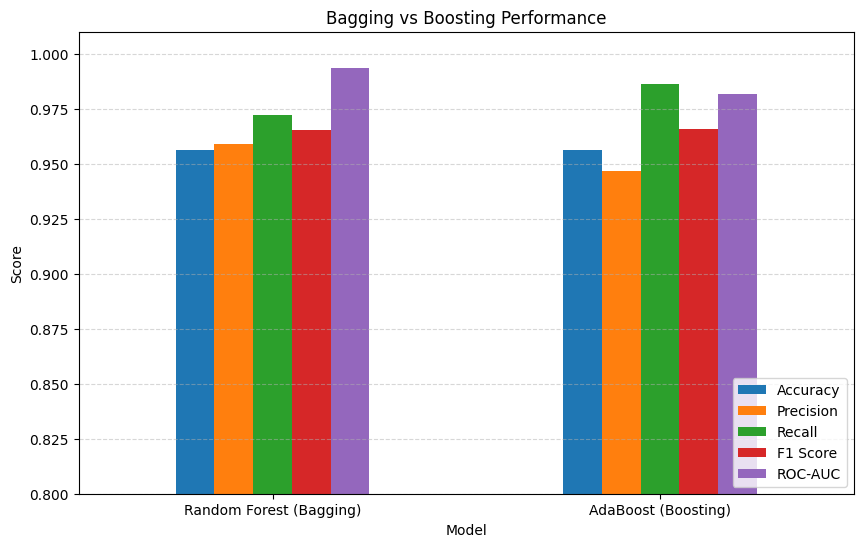

In [13]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0.8, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

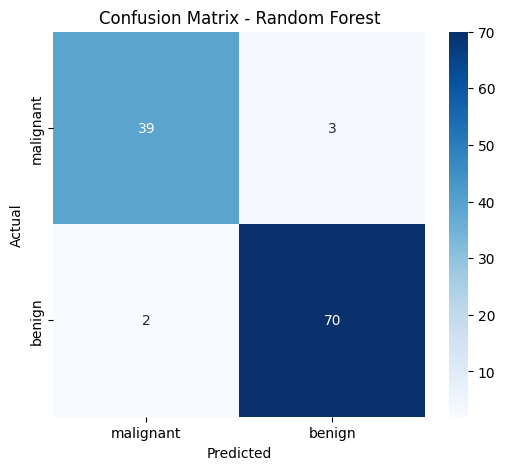

In [12]:
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bagging,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

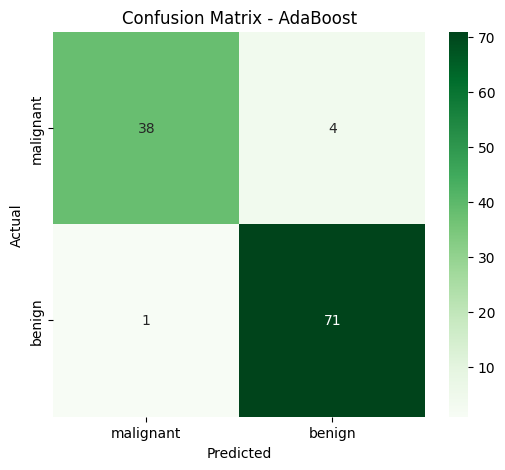

In [11]:
cm_boosting = confusion_matrix(y_test, y_pred_boosting)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_boosting,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost")

plt.show()

In [10]:
print("========== FINAL COMPARISON ==========\n")

for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]:
    bagging_score = results.loc[
        results["Model"] == "Random Forest (Bagging)", metric
    ].values[0]

    boosting_score = results.loc[
        results["Model"] == "AdaBoost (Boosting)", metric
    ].values[0]

    print(f"{metric}:")
    print(f"  Random Forest : {bagging_score:.4f}")
    print(f"  AdaBoost      : {boosting_score:.4f}")
    print()

========== FINAL COMPARISON ==========

Accuracy:
  Random Forest : 0.9561
  AdaBoost      : 0.9561

Precision:
  Random Forest : 0.9589
  AdaBoost      : 0.9467

Recall:
  Random Forest : 0.9722
  AdaBoost      : 0.9861

F1 Score:
  Random Forest : 0.9655
  AdaBoost      : 0.9660

ROC-AUC:
  Random Forest : 0.9937
  AdaBoost      : 0.9818

